# IE406 - Machine Learning
## Lab 1: Linear Regression using Mini-Batch Gradient Descent
**Student ID:** 202401029

## Task 1: Dataset Preparation
### 1.1 Load the Dataset

In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
%matplotlib inline

data = fetch_california_housing()
X = data.data.copy()
y = data.target.copy()

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Feature names:", data.feature_names)
print("Target range:", y.min(), "to", y.max())

Samples: 20640
Features: 8
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target range: 0.14999 to 5.00001


### 1.2 Train-Validation-Test Split (60/20/20)

In [2]:
np.random.seed(9432)

N = X.shape[0]
indices = np.random.permutation(N)

train_end = int(0.6 * N)
val_end = int(0.8 * N)

X_train, y_train = X[indices[:train_end]], y[indices[:train_end]]
X_val, y_val = X[indices[train_end:val_end]], y[indices[train_end:val_end]]
X_test, y_test = X[indices[val_end:]], y[indices[val_end:]]

print("Train:", X_train.shape[0])
print("Val:", X_val.shape[0])
print("Test:", X_test.shape[0])

Train: 12384
Val: 4128
Test: 4128


### 1.3 Feature Normalization
Mean and standard deviation computed from training set only (Note: the PDF mentions "test set" in point 3, which is a typo — it should be training set).

In [3]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

print("After normalization (train set):")
print("Mean:", np.round(X_train_norm.mean(axis=0), 10))
print("Std:", np.round(X_train_norm.std(axis=0), 6))

After normalization (train set):
Mean: [ 0. -0. -0. -0. -0.  0.  0. -0.]
Std: [1. 1. 1. 1. 1. 1. 1. 1.]


### 1.4 Feature Augmentation
Adding a column of 1s for the bias term.

In [4]:
X_train_aug = np.hstack([X_train_norm, np.ones((X_train_norm.shape[0], 1))])
X_val_aug = np.hstack([X_val_norm, np.ones((X_val_norm.shape[0], 1))])
X_test_aug = np.hstack([X_test_norm, np.ones((X_test_norm.shape[0], 1))])

print("Shape after augmentation:", X_train_aug.shape)

Shape after augmentation: (12384, 9)


### 1.5 Standardize Targets
Using training set mean and std for all sets.

In [5]:
y_mean = y_train.mean()
y_std = y_train.std()

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

print("Target mean (train):", round(y_mean, 4))
print("Target std (train):", round(y_std, 4))
print("After normalization - mean:", round(y_train_norm.mean(), 8), "std:", round(y_train_norm.std(), 6))

Target mean (train): 2.0583
Target std (train): 1.1574
After normalization - mean: 0.0 std: 1.0


## Task 2: Mini-Batch Gradient Descent Implementation

In [6]:
def train_linear_regression(X_train, y_train, X_val, y_val, lr, batch_size, max_epochs=1000, patience=100):

    n_samples, n_features = X_train.shape
    w = np.zeros(n_features)

    best_val_mse = float('inf')
    best_w = w.copy()
    best_epoch = 0
    no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(max_epochs):
        perm = np.random.permutation(n_samples)
        X_shuf = X_train[perm]
        y_shuf = y_train[perm]

        loss_sum = 0.0
        count = 0

        for start in range(0, n_samples, batch_size):
            xb = X_shuf[start:start + batch_size]
            yb = y_shuf[start:start + batch_size]
            b_n = xb.shape[0]

            pred = xb @ w
            err = pred - yb
            mse = np.mean(err ** 2)

            loss_sum += mse * b_n
            count += b_n

            grad = (2.0 / b_n) * (xb.T @ err)
            w = w - lr * grad

            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return best_w, train_losses, val_losses, best_epoch, best_val_mse

        train_mse = loss_sum / count
        train_losses.append(train_mse)

        val_pred = X_val @ w
        val_mse = np.mean((val_pred - y_val) ** 2)
        val_losses.append(val_mse)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_w = w.copy()
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return best_w, train_losses, val_losses, best_epoch, best_val_mse

## Task 3: Effect of Learning Rate
Batch size = 128 for all experiments.

In [7]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

lr_results = {}

for lr in learning_rates:
    best_w, t_loss, v_loss, best_ep, best_vmse = train_linear_regression(
        X_train_aug, y_train_norm, X_val_aug, y_val_norm,
        lr=lr, batch_size=128
    )
    lr_results[lr] = {
        'w': best_w, 'train': t_loss, 'val': v_loss,
        'epoch': best_ep, 'vmse': best_vmse
    }
    print(f"lr={lr:<10g}  best_val_mse={best_vmse:.6f}  best_epoch={best_ep+1}  total_epochs={len(t_loss)}")

lr=1e-05       best_val_mse=0.471494  best_epoch=1000  total_epochs=1000


lr=0.0001      best_val_mse=0.396836  best_epoch=1000  total_epochs=1000


lr=0.001       best_val_mse=0.391687  best_epoch=307  total_epochs=407
lr=0.01        best_val_mse=0.390452  best_epoch=26  total_epochs=126


lr=0.1         best_val_mse=101.942859  best_epoch=1  total_epochs=101
lr=1           best_val_mse=146829087669241888445128157214066007259395149422794795188249711809074328159999440858382336.000000  best_epoch=1  total_epochs=6
lr=10          best_val_mse=inf  best_epoch=1  total_epochs=2


/var/folders/wf/ks2jw8h15rx8759z_55sspzr0000gn/T/ipykernel_2672/3085717123.py:44: RuntimeWarning: overflow encountered in square
  val_mse = np.mean((val_pred - y_val) ** 2)
/var/folders/wf/ks2jw8h15rx8759z_55sspzr0000gn/T/ipykernel_2672/3085717123.py:29: RuntimeWarning: overflow encountered in square
  mse = np.mean(err ** 2)
/Users/yugmalaviya/Desktop/ACAD/ML/venv/lib/python3.14/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/wf/ks2jw8h15rx8759z_55sspzr0000gn/T/ipykernel_2672/3085717123.py:31: RuntimeWarning: overflow encountered in scalar add
  loss_sum += mse * b_n


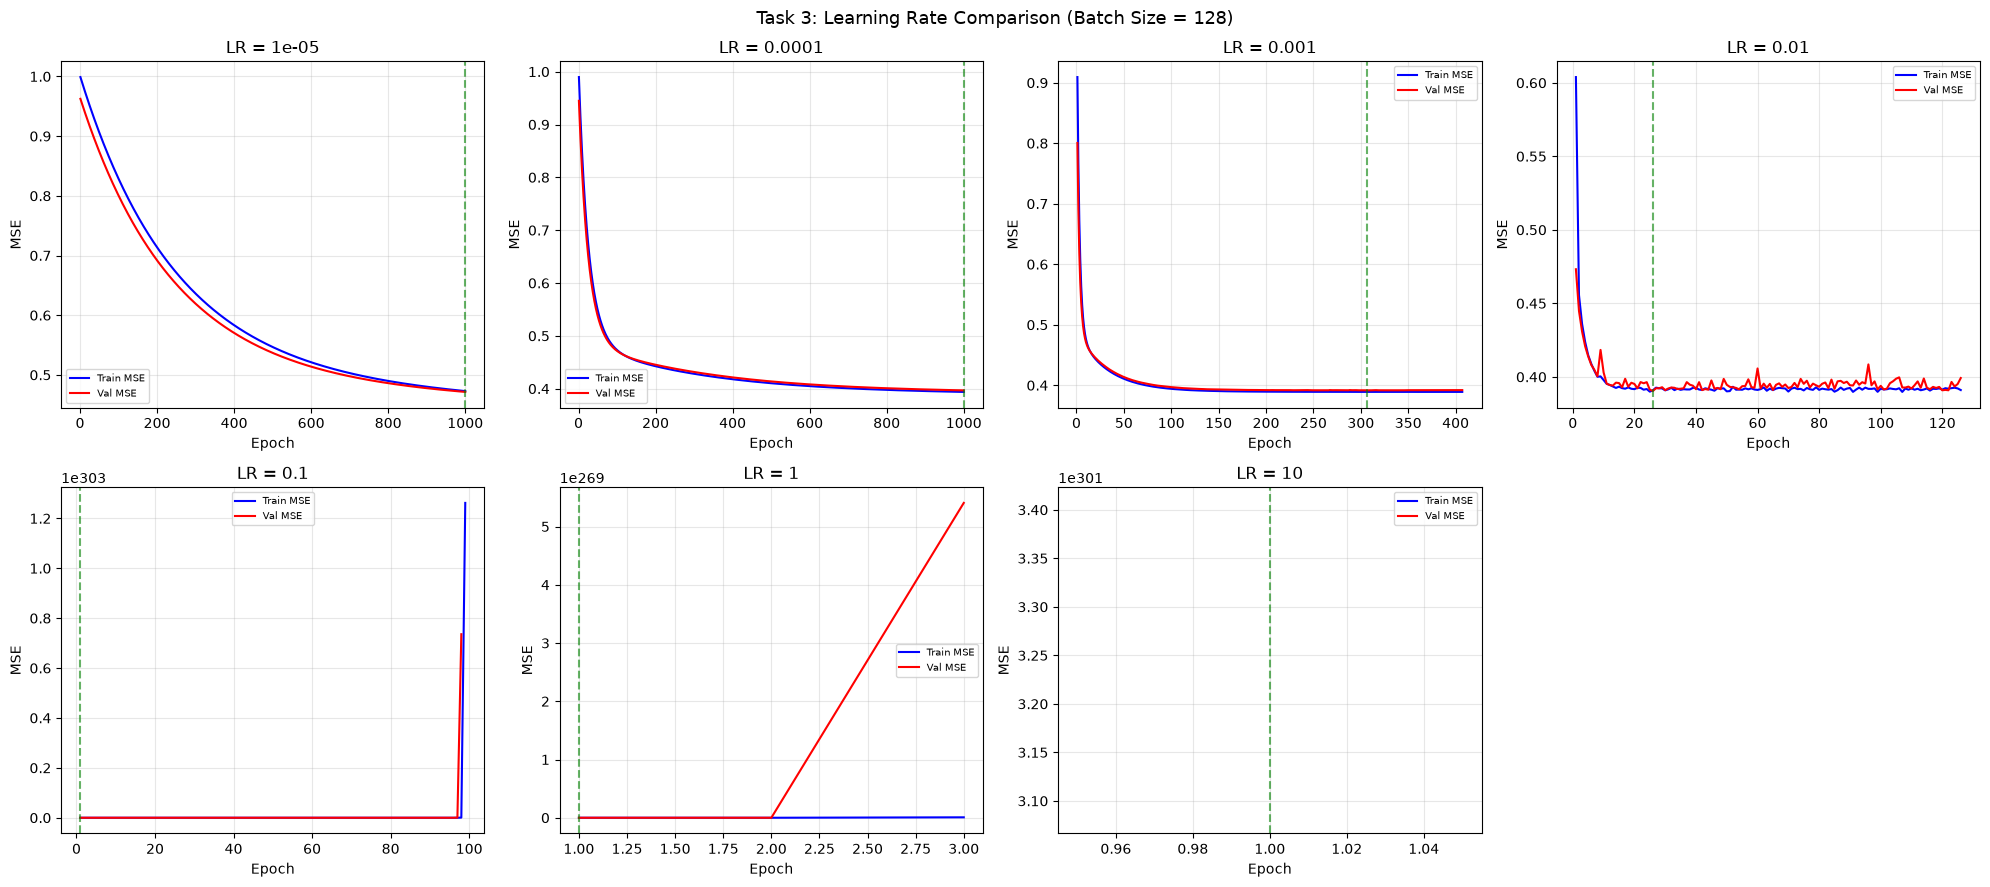

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, lr in enumerate(learning_rates):
    ax = axes[i]
    res = lr_results[lr]
    ep = range(1, len(res['train']) + 1)
    ax.plot(ep, res['train'], label='Train MSE', color='blue')
    ax.plot(ep, res['val'], label='Val MSE', color='red')
    ax.axvline(res['epoch'] + 1, color='green', linestyle='--', alpha=0.6)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_title(f'LR = {lr}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[7].set_visible(False)
plt.suptitle('Task 3: Learning Rate Comparison (Batch Size = 128)', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
print(f"{'LR':>12}  {'Best Val MSE':>14}  {'Best Epoch':>10}  {'Epochs':>8}")
print("-" * 50)

best_lr = None
best_lr_mse = float('inf')

for lr in learning_rates:
    r = lr_results[lr]
    print(f"{lr:>12g}  {r['vmse']:>14.6f}  {r['epoch']+1:>10}  {len(r['train']):>8}")
    if r['vmse'] < best_lr_mse:
        best_lr_mse = r['vmse']
        best_lr = lr

print(f"\nBest learning rate: {best_lr}")

          LR    Best Val MSE  Best Epoch    Epochs
--------------------------------------------------
       1e-05        0.471494        1000      1000
      0.0001        0.396836        1000      1000
       0.001        0.391687         307       407
        0.01        0.390452          26       126
         0.1      101.942859           1       101
           1  146829087669241888445128157214066007259395149422794795188249711809074328159999440858382336.000000           1         6
          10             inf           1         2

Best learning rate: 0.01


## Task 4: Effect of Batch Size
Using the best learning rate found above.

In [10]:
n_train = X_train_aug.shape[0]
batch_sizes = [1, 16, 32, 64, 128, 256, n_train]

bs_results = {}

print(f"Learning rate: {best_lr}\n")

for bs in batch_sizes:
    label = str(bs) if bs != n_train else f"{bs} (full)"
    best_w, t_loss, v_loss, best_ep, best_vmse = train_linear_regression(
        X_train_aug, y_train_norm, X_val_aug, y_val_norm,
        lr=best_lr, batch_size=bs
    )
    bs_results[bs] = {
        'label': label, 'w': best_w, 'train': t_loss, 'val': v_loss,
        'epoch': best_ep, 'vmse': best_vmse
    }
    print(f"bs={label:<14}  best_val_mse={best_vmse:.6f}  best_epoch={best_ep+1}  epochs={len(t_loss)}")

Learning rate: 0.01



/var/folders/wf/ks2jw8h15rx8759z_55sspzr0000gn/T/ipykernel_2672/3085717123.py:31: RuntimeWarning: overflow encountered in scalar add
  loss_sum += mse * b_n
/var/folders/wf/ks2jw8h15rx8759z_55sspzr0000gn/T/ipykernel_2672/3085717123.py:44: RuntimeWarning: overflow encountered in square
  val_mse = np.mean((val_pred - y_val) ** 2)
/var/folders/wf/ks2jw8h15rx8759z_55sspzr0000gn/T/ipykernel_2672/3085717123.py:29: RuntimeWarning: overflow encountered in square
  mse = np.mean(err ** 2)


bs=1               best_val_mse=426304.974008  best_epoch=1  epochs=101


bs=16              best_val_mse=0.479729  best_epoch=1  epochs=101


bs=32              best_val_mse=5.199557  best_epoch=1  epochs=101


bs=64              best_val_mse=0.390534  best_epoch=60  epochs=160


bs=128             best_val_mse=0.391039  best_epoch=99  epochs=199


bs=256             best_val_mse=0.390844  best_epoch=248  epochs=348


bs=12384 (full)    best_val_mse=0.396396  best_epoch=1000  epochs=1000


In [11]:
print(f"\n{'Batch Size':>18}  {'Lowest Val MSE':>15}  {'Epoch':>6}")
print("-" * 45)

best_bs = None
best_bs_mse = float('inf')

for bs in batch_sizes:
    r = bs_results[bs]
    print(f"{r['label']:>18}  {r['vmse']:>15.6f}  {r['epoch']+1:>6}")
    if r['vmse'] < best_bs_mse:
        best_bs_mse = r['vmse']
        best_bs = bs

print(f"\nBest batch size: {bs_results[best_bs]['label']}")


        Batch Size   Lowest Val MSE   Epoch
---------------------------------------------
                 1    426304.974008       1
                16         0.479729       1
                32         5.199557       1
                64         0.390534      60
               128         0.391039      99
               256         0.390844     248
      12384 (full)         0.396396    1000

Best batch size: 64


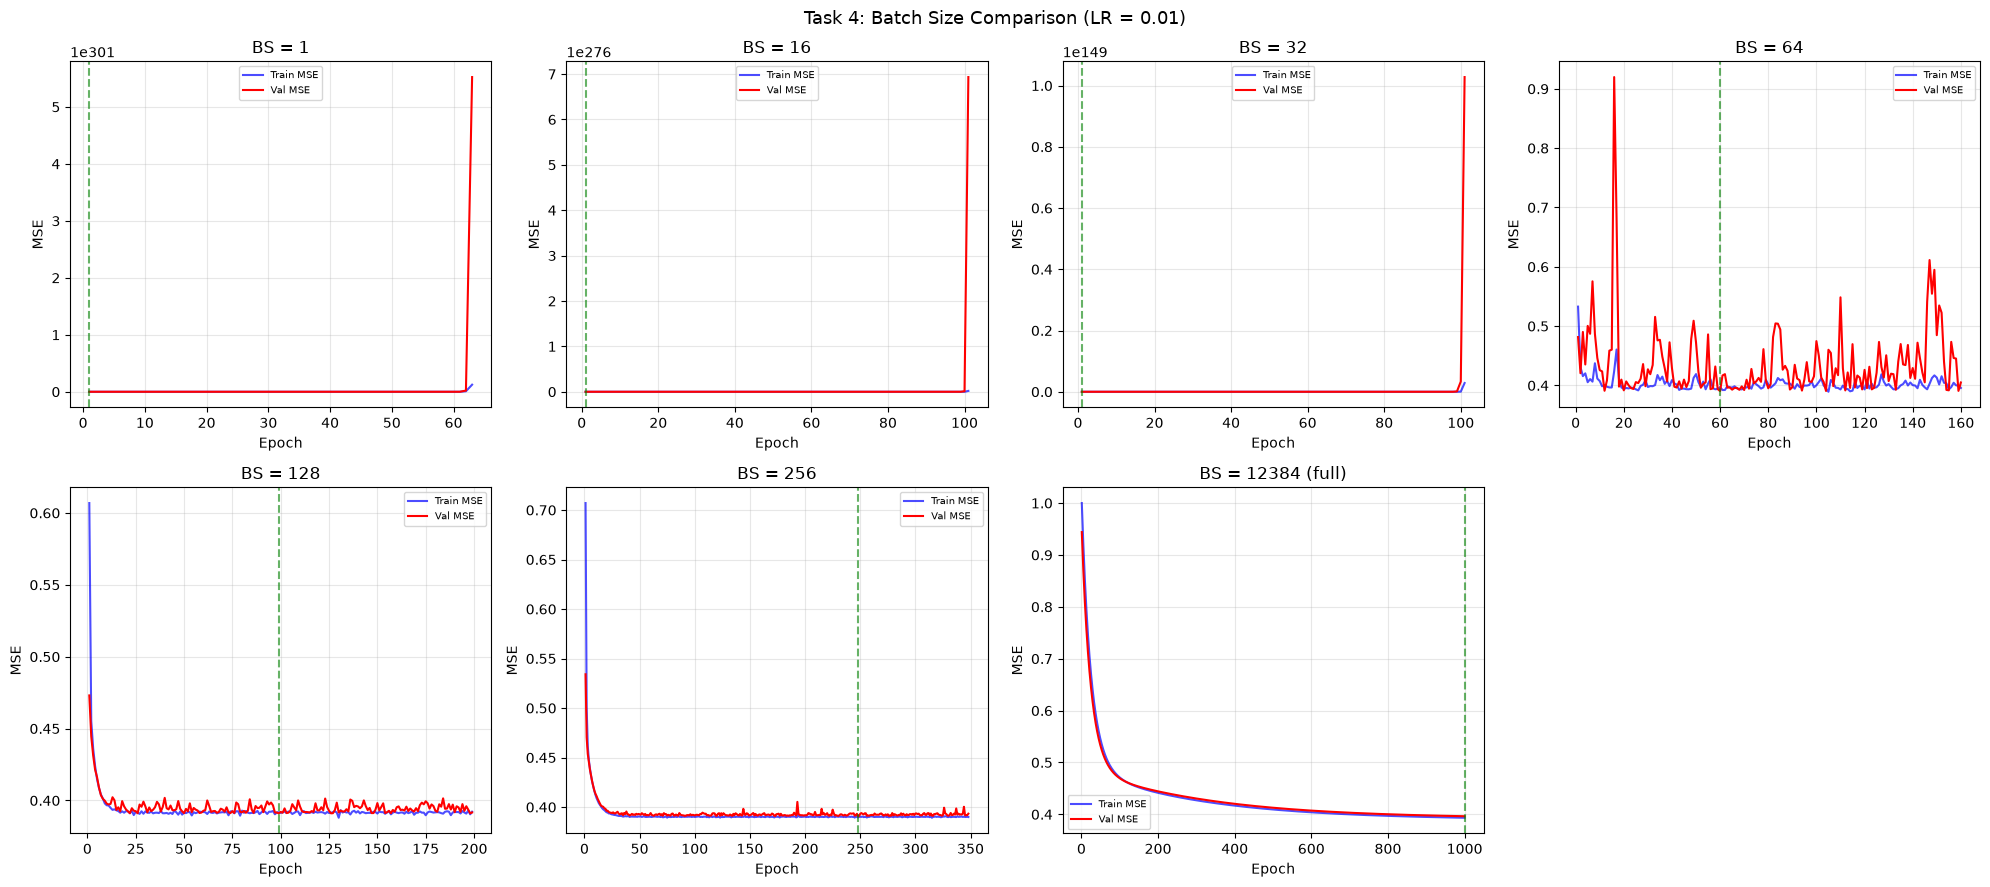

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, bs in enumerate(batch_sizes):
    ax = axes[i]
    res = bs_results[bs]
    ep = range(1, len(res['train']) + 1)
    ax.plot(ep, res['train'], label='Train MSE', color='blue', alpha=0.7)
    ax.plot(ep, res['val'], label='Val MSE', color='red')
    ax.axvline(res['epoch'] + 1, color='green', linestyle='--', alpha=0.6)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_title(f"BS = {res['label']}")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[7].set_visible(False)
plt.suptitle(f'Task 4: Batch Size Comparison (LR = {best_lr})', fontsize=13)
plt.tight_layout()
plt.show()

## Task 5: Test Set Evaluation
Using best model from Task 3 and 4.

In [13]:
def get_metrics(X, y_orig, w, y_mean, y_std):
    pred_norm = X @ w
    pred = pred_norm * y_std + y_mean

    rmse = np.sqrt(np.mean((pred - y_orig) ** 2))
    mae = np.mean(np.abs(pred - y_orig))
    mape = np.mean(np.abs((pred - y_orig) / y_orig)) * 100
    ss_res = np.sum((pred - y_orig) ** 2)
    ss_tot = np.sum((y_orig - np.mean(y_orig)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return rmse, mae, mape, r2, pred

In [14]:
w_best = bs_results[best_bs]['w']

train_rmse, train_mae, train_mape, train_r2, _ = get_metrics(X_train_aug, y_train, w_best, y_mean, y_std)
val_rmse, val_mae, val_mape, val_r2, _ = get_metrics(X_val_aug, y_val, w_best, y_mean, y_std)
test_rmse, test_mae, test_mape, test_r2, test_pred = get_metrics(X_test_aug, y_test, w_best, y_mean, y_std)

print(f"Best model: lr={best_lr}, batch_size={bs_results[best_bs]['label']}, epoch={bs_results[best_bs]['epoch']+1}")
print()
print(f"{'Metric':>10}  {'Train':>12}  {'Val':>12}  {'Test':>12}")
print("-" * 52)
print(f"{'RMSE':>10}  {train_rmse:>12.5f}  {val_rmse:>12.5f}  {test_rmse:>12.5f}")
print(f"{'MAE':>10}  {train_mae:>12.5f}  {val_mae:>12.5f}  {test_mae:>12.5f}")
print(f"{'MAPE(%)':>10}  {train_mape:>12.5f}  {val_mape:>12.5f}  {test_mape:>12.5f}")
print(f"{'R-squared':>10}  {train_r2:>12.5f}  {val_r2:>12.5f}  {test_r2:>12.5f}")

Best model: lr=0.01, batch_size=64, epoch=60

    Metric         Train           Val          Test
----------------------------------------------------
      RMSE       0.72348       0.72330       0.73027
       MAE       0.52651       0.53163       0.53028
   MAPE(%)      31.41714      31.27045      31.13994
 R-squared       0.60927       0.59507       0.60372


### Actual vs Predicted (Test Set)

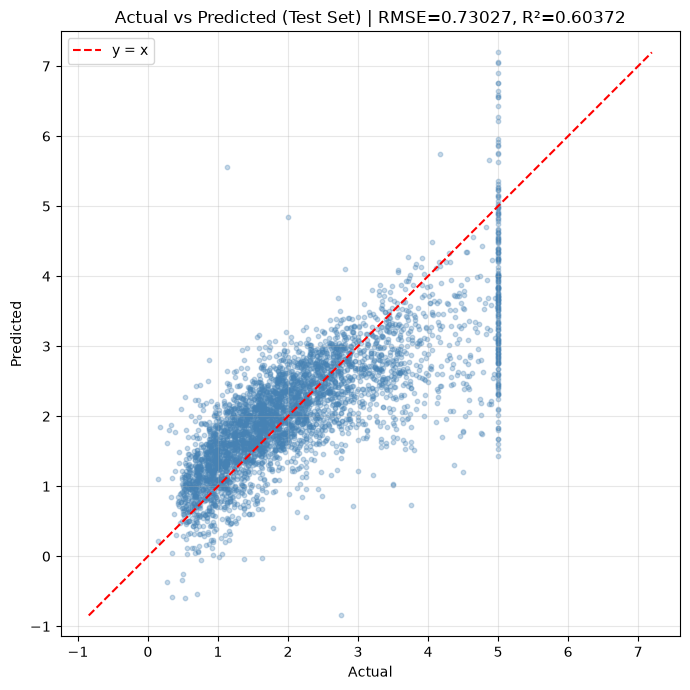

In [15]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_pred, alpha=0.3, s=10, color='steelblue')

mn = min(y_test.min(), test_pred.min())
mx = max(y_test.max(), test_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='y = x')

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Actual vs Predicted (Test Set) | RMSE={test_rmse:.5f}, R²={test_r2:.5f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()